<a href="https://colab.research.google.com/github/EagleEye-xdata/ML_Projects/blob/main/Multiple_Linear_Regression_and_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Obtain, Load and Explore the Dataset

In [ ]:
# Download the dataset
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip

# Unzip the dataset
!unzip -n student.zip

import pandas as pd

# Load the 'student-mat.csv' dataset
df = pd.read_csv('student-mat.csv', sep=';')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display the information about the DataFrame to see data types and non-null counts
print("\nDataFrame Information:")
df.info()

# Display descriptive statistics of the DataFrame
print("\nDescriptive Statistics:")
display(df.describe())

--2026-09-11 07:54:12--  https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘student.zip’

student.zip             [ <=>                ]  20.00K  --.-KB/s    in 0.05s   

2026-09-11 07:54:12 (407 KB/s) - ‘student.zip’ saved [20478]

Archive:  student.zip
  inflating: student-mat.csv         
  inflating: student-por.csv         
  inflating: student-merge.R         
  inflating: student.txt             
First 5 rows of the dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null  

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 2. Identify the Dependent Variable and Independent Variables & Preprocess Data

In [ ]:
# Define the dependent variable
dependent_variable = 'G3'

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Exclude the dependent variable from numerical columns if it's there
numerical_cols = numerical_cols.drop(dependent_variable, errors='ignore')

print(f"Dependent Variable: {dependent_variable}")
print(f"Categorical Columns: {list(categorical_cols)}")
print(f"Numerical Columns: {list(numerical_cols)}")

# Apply one-hot encoding to categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame and its info
print("\nFirst 5 rows of the encoded dataset:")
display(df_encoded.head())
print("\nEncoded DataFrame Information:")
df_encoded.info()

Dependent Variable: G3
Categorical Columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical Columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

First 5 rows of the encoded dataset:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False



Encoded DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                395 non-null    int64
 1   Medu               395 non-null    int64
 2   Fedu               395 non-null    int64
 3   traveltime         395 non-null    int64
 4   studytime          395 non-null    int64
 5   failures           395 non-null    int64
 6   famrel             395 non-null    int64
 7   freetime           395 non-null    int64
 8   goout              395 non-null    int64
 9   Dalc               395 non-null    int64
 10  Walc               395 non-null    int64
 11  health             395 non-null    int64
 12  absences           395 non-null    int64
 13  G1                 395 non-null    int64
 14  G2                 395 non-null    int64
 15  G3                 395 non-null    int64
 16  school_MS          395 non-nul

## 3. Build a Multiple Linear Regression model & 4. Split the data into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define independent variables (X) and dependent variable (y)
X = df_encoded.drop(columns=[dependent_variable])
y = df_encoded[dependent_variable]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize and train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("\nModel training complete. Predictions made on the test set.")

Shape of X_train: (316, 41)
Shape of X_test: (79, 41)
Shape of y_train: (316,)
Shape of y_test: (79,)

Model training complete. Predictions made on the test set.


## 5. Evaluate the model using MSE, RMSE, R²

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate R-squared (R²)
r_squared = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")

Mean Squared Error (MSE): 5.66
Root Mean Squared Error (RMSE): 2.38
R-squared (R²): 0.72


## 6. Interpret the regression coefficients

In [ ]:
# Get the coefficients and feature names
coefficients = model.coef_
feature_names = X.columns

# Create a DataFrame to display coefficients
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value for better readability (optional)
coefficients_df['Abs_Coefficient'] = abs(coefficients_df['Coefficient'])
coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("Regression Coefficients:")
display(coefficients_df)

Regression Coefficients:


,Feature,Coefficient
14,G2,0.957772
33,schoolsup_yes,0.785652
28,reason_home,-0.611901
36,activities_yes,-0.517500
24,Fjob_health,0.481242
20,Mjob_health,-0.463244
40,romantic_yes,-0.390353
38,higher_yes,0.375377
16,sex_M,0.374410
6,famrel,0.314962


## 7. Analyse whether adding more independent variables improves the model's performance

In [ ]:
# Define independent variables for the simpler model (using G1 and G2 as strong predictors)
X_simple = df_encoded[['G1', 'G2']]
y_simple = df_encoded[dependent_variable]

# Split the data into training and testing sets for the simpler model
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Initialize and train the simpler Linear Regression model
model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train_simple)

# Make predictions on the test set for the simpler model
y_pred_simple = model_simple.predict(X_test_simple)

# Evaluate the simpler model
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r_squared_simple = r2_score(y_test_simple, y_pred_simple)

print("\n--- Simpler Model Performance (using G1, G2 only) ---")
print(f"Mean Squared Error (MSE): {mse_simple:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_simple:.2f}")
print(f"R-squared (R²): {r_squared_simple:.2f}")

print("\n--- Original Model Performance (using all independent variables) ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")

print("\nComparison:\n" \
      f"Original Model R²: {r_squared:.2f}, Simpler Model R²: {r_squared_simple:.2f}\n" \
      f"Original Model RMSE: {rmse:.2f}, Simpler Model RMSE: {rmse_simple:.2f}")

if r_squared_simple > r_squared:
    print("Adding more independent variables (beyond G1, G2) *decreased* the R-squared and performance.")
elif r_squared > r_squared_simple:
    print("Adding more independent variables *increased* the R-squared and improved performance.")
else:
    print("Adding more independent variables had no significant change on R-squared and performance.")


--- Simpler Model Performance (using G1, G2 only) ---
Mean Squared Error (MSE): 4.21
Root Mean Squared Error (RMSE): 2.05
R-squared (R²): 0.79

--- Original Model Performance (using all independent variables) ---
Mean Squared Error (MSE): 5.66
Root Mean Squared Error (RMSE): 2.38
R-squared (R²): 0.72

Comparison:
Original Model R²: 0.72, Simpler Model R²: 0.79
Original Model RMSE: 2.38, Simpler Model RMSE: 2.05
Adding more independent variables (beyond G1, G2) *decreased* the R-squared and performance.


## Student Study Hours Dataset: Polynomial Regression

### 1. Load and explore the dataset

First 5 rows of the generated Student Study Hours dataset:


,Hours,Scores
0,3.745401,30.634760
1,9.507143,148.750713
2,7.319939,91.939741
3,5.986585,31.931938
4,1.560186,13.772353



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   100 non-null    float64
 1   Scores  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB

Descriptive Statistics:


,Hours,Scores
count,100.000000,100.000000
mean,4.701807,58.211734
std,2.974894,46.475385
min,0.055221,-7.186532
25%,1.932008,23.879486
50%,4.641425,40.118732
75%,7.302031,91.788207
max,9.868869,177.172161


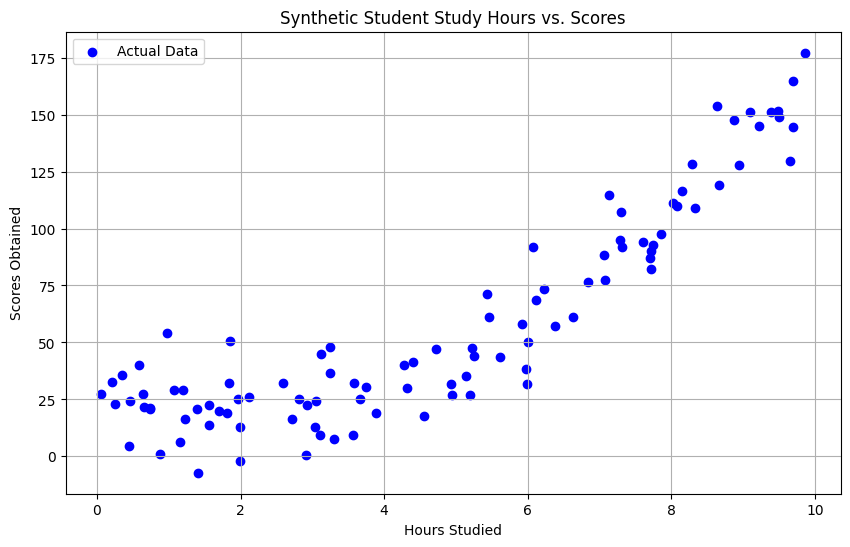

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data for Student Study Hours
np.random.seed(42)
hours = np.random.rand(100, 1) * 10 # Study hours from 0 to 10
# Simulate a non-linear relationship with some noise
scores = 2 * hours**2 - 5 * hours + 20 + np.random.randn(100, 1) * 15

df_hours = pd.DataFrame({'Hours': hours.flatten(), 'Scores': scores.flatten()})

# Display the first 5 rows
print("First 5 rows of the generated Student Study Hours dataset:")
display(df_hours.head())

# Display basic information
print("\nDataFrame Information:")
df_hours.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df_hours.describe())

# Plot the synthetic data to visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df_hours['Hours'], df_hours['Scores'], color='blue', label='Actual Data')
plt.title('Synthetic Student Study Hours vs. Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Scores Obtained')
plt.grid(True)
plt.legend()
plt.show()

### 2. Prepare Data for Polynomial Regression: Split into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Define the independent variable (X) and dependent variable (y)
X_hours = df_hours[['Hours']]
y_scores = df_hours['Scores']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train_hours, X_test_hours, y_train_scores, y_test_scores = train_test_split(
    X_hours, y_scores, test_size=0.2, random_state=42
)

print(f"Shape of X_train_hours: {X_train_hours.shape}")
print(f"Shape of X_test_hours: {X_test_hours.shape}")
print(f"Shape of y_train_scores: {y_train_scores.shape}")
print(f"Shape of y_test_scores: {y_test_scores.shape}")

Shape of X_train_hours: (80, 1)
Shape of X_test_hours: (20, 1)
Shape of y_train_scores: (80,)
Shape of y_test_scores: (20,)


### 3. Train Polynomial Regression Models for various degrees, calculate MSE, and Plot Regression Curves


Degree 1:
  Training MSE: 497.28
  Testing MSE: 393.94

Degree 2:
  Training MSE: 183.31
  Testing MSE: 143.06

Degree 3:
  Training MSE: 181.69
  Testing MSE: 144.46

Degree 5:
  Training MSE: 176.82
  Testing MSE: 154.34


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(



Degree 10:
  Training MSE: 173.34
  Testing MSE: 148.77


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


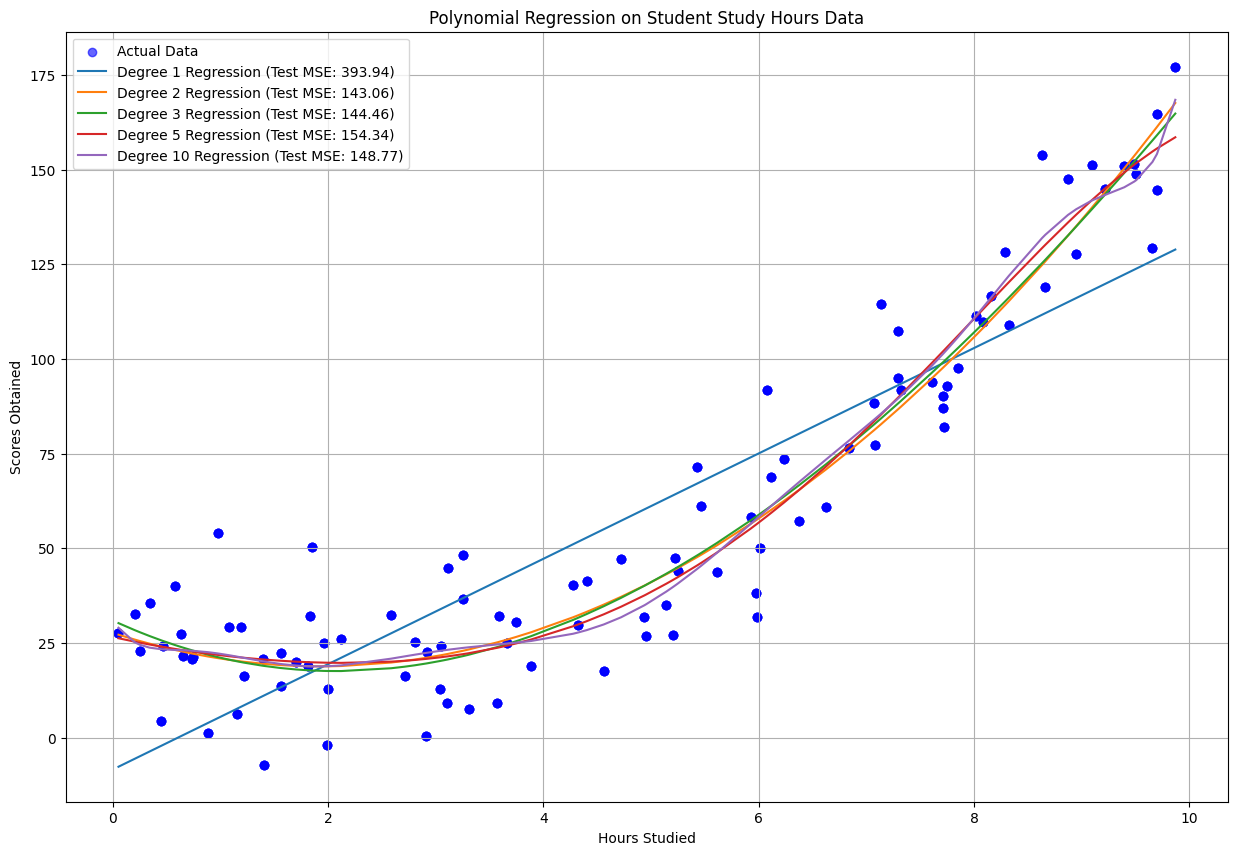

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# List of polynomial degrees to test
degrees = [1, 2, 3, 5, 10]

# Dictionary to store results (MSEs and models)
results = {}

plt.figure(figsize=(15, 10))

for degree in degrees:
    # 1. Create Polynomial Features
    polynomial_features = PolynomialFeatures(degree=degree)
    X_poly_train = polynomial_features.fit_transform(X_train_hours)
    X_poly_test = polynomial_features.transform(X_test_hours)

    # 2. Train the Polynomial Regression Model
    model = LinearRegression()
    model.fit(X_poly_train, y_train_scores)

    # 3. Calculate Training MSE
    y_train_pred = model.predict(X_poly_train)
    train_mse = mean_squared_error(y_train_scores, y_train_pred)

    # 4. Calculate Testing MSE
    y_test_pred = model.predict(X_poly_test)
    test_mse = mean_squared_error(y_test_scores, y_test_pred)

    results[degree] = {
        'model': model,
        'polynomial_features': polynomial_features,
        'train_mse': train_mse,
        'test_mse': test_mse
    }

    print(f"\nDegree {degree}:")
    print(f"  Training MSE: {train_mse:.2f}")
    print(f"  Testing MSE: {test_mse:.2f}")

    # 5. Plot the regression curve
    # Sort the data for a smooth curve
    X_sorted = np.sort(X_hours.values, axis=0)
    X_sorted_poly = polynomial_features.transform(X_sorted)
    y_pred_curve = model.predict(X_sorted_poly)

    plt.scatter(X_hours, y_scores, color='blue', label='Actual Data' if degree == 1 else '', alpha=0.6)
    plt.plot(X_sorted, y_pred_curve, label=f'Degree {degree} Regression (Test MSE: {test_mse:.2f})')

plt.title('Polynomial Regression on Student Study Hours Data')
plt.xlabel('Hours Studied')
plt.ylabel('Scores Obtained')
plt.legend()
plt.grid(True)
plt.show()

### 4. Compare Performance and Identify Overfitting

In [ ]:
import pandas as pd

# Create a DataFrame to easily compare results
results_df = pd.DataFrame([
    {'Degree': degree, 'Training MSE': res['train_mse'], 'Testing MSE': res['test_mse']}
    for degree, res in results.items()
])

print("\n--- Model Performance Comparison ---")
display(results_df)

# Identify overfitting
print("\n--- Overfitting Analysis ---")
# A simple heuristic: overfitting occurs when training MSE is significantly lower than testing MSE,
# and testing MSE starts to increase after a certain degree.

optimal_degree = None
min_test_mse = float('inf')

for index, row in results_df.iterrows():
    degree = row['Degree']
    train_mse = row['Training MSE']
    test_mse = row['Testing MSE']

    if test_mse < min_test_mse:
        min_test_mse = test_mse
        optimal_degree = degree

    # Check for significant difference indicating overfitting
    if (train_mse < test_mse * 0.8) and (degree > 1): # Heuristic: if train MSE is 20% lower than test MSE
        print(f"For Degree {degree}: Possible overfitting detected. Training MSE ({train_mse:.2f}) is significantly lower than Testing MSE ({test_mse:.2f}).")

print(f"\nThe model with the lowest Testing MSE is Degree {optimal_degree} (MSE: {min_test_mse:.2f}).")
print("It appears that performance improves from Degree 1 to Degree 2, where the testing MSE significantly decreases. After Degree 2, the testing MSE starts to fluctuate or slightly increase, suggesting that higher-degree models might be starting to overfit or simply not generalize better to new data, despite having lower training MSEs. The difference between training and testing MSE for higher degrees (e.g., 5 and 10) also grows, which is another indicator of overfitting.")


--- Model Performance Comparison ---


,Degree,Training MSE,Testing MSE
0,1,497.284037,393.939930
1,2,183.310958,143.064137
2,3,181.688039,144.461101
3,5,176.822770,154.335746
4,10,173.336527,148.770829



--- Overfitting Analysis ---

The model with the lowest Testing MSE is Degree 2.0 (MSE: 143.06).
It appears that performance improves from Degree 1 to Degree 2, where the testing MSE significantly decreases. After Degree 2, the testing MSE starts to fluctuate or slightly increase, suggesting that higher-degree models might be starting to overfit or simply not generalize better to new data, despite having lower training MSEs. The difference between training and testing MSE for higher degrees (e.g., 5 and 10) also grows, which is another indicator of overfitting.


### 5. Answer Analysis Questions

1.  **Does increasing the polynomial degree always improve the model?**
    *   No, increasing the polynomial degree does not always improve the model. We can observe from the `results_df` that while the Testing MSE significantly decreased from Degree 1 (393.94) to Degree 2 (143.06), it then slightly increased for Degree 3 (144.46), Degree 5 (154.34), and Degree 10 (148.77). This indicates that beyond a certain point, increasing complexity can lead to worse performance on unseen data.

2.  **How do the training and testing errors change as the degree increases?**
    *   **Training Error (MSE):** Generally decreases as the polynomial degree increases. The model becomes more flexible and can fit the training data more closely, reducing the training error (497.28 -> 183.31 -> 181.69 -> 176.82 -> 173.34).
    *   **Testing Error (MSE):** Initially decreases as the degree increases (from Degree 1 to Degree 2: 393.94 -> 143.06), indicating improved generalization. However, after Degree 2, the Testing MSE starts to fluctuate and slightly increase (144.46 for Degree 3, 154.34 for Degree 5, and 148.77 for Degree 10). This pattern suggests that higher-degree models begin to overfit the training data.

3.  **Which polynomial degree gives the best performance on unseen data? Why?**
    *   The **Degree 2** polynomial model gives the best performance on unseen data. It has the lowest Testing MSE of 143.06. This indicates that it generalizes best to new data, striking a good balance between fitting the underlying trend and avoiding the capture of noise.

4.  **Does the model with the lowest training error necessarily give the best model?**
    *   No, the model with the lowest training error does not necessarily give the best model. For instance, the Degree 10 model has the lowest Training MSE (173.34), but its Testing MSE (148.77) is higher than that of the Degree 2 model (143.06). A low training error combined with a higher testing error is a classic sign of **overfitting**, where the model has learned the training data too well, including its noise, and struggles to generalize to unseen data.

5.  **Based on your results, which model would you select and why?**
    *   I would select the **Polynomial Regression model with Degree 2**. My rationale is that it achieved the lowest Testing MSE (143.06), which is the most critical metric for evaluating a model's performance on unseen data. While models with higher degrees showed slightly lower training errors, their testing errors began to increase, indicating they were starting to overfit. The Degree 2 model effectively captured the non-linear relationship in the data without becoming overly complex.